# nb14b — Investigate persistent capture structure

Follow-up to nb14: separate donor/site composition, within-population capture
structure, shared versus heterogeneous capture directions, and recurring RNA
differences. **No generative model retraining and no paired-cell assumptions.**

Use the exact nb14 evaluation sample. Comparisons require ≥50 cells per capture
within donor × site × harmonized population. Balance up to 250 per capture within
these strata using seeds 42–44. Population classifiers require at least two training
donors, and hold out the entire test donor. Standardization and projection directions
use only training donors. Both captures remain represented at matched sites.

Sequential linear classifier directions are removed only as a diagnostic. Compare
rank 1, rank 3 and a random rank-3 negative control. Each held-out donor is evaluated
separately: **fold-specific coordinates are never combined into a corrected space**.
Refit classifiers after projection to detect remaining linearly predictable capture
information. Global mixing and purity use all cells of that held-out donor; group
alignment uses adequately sized site/population strata. Do not compare those global
fractions directly with nb14's all-donor neighborhoods.

Also report removed within-stratum variance and an orientation-free AUROC diagnostic:
max(AUROC, 1−AUROC) distinguishes reversed held-donor relations from loss of
separability. This uses test labels post hoc and is **not** predictive accuracy.
An RNA-QC-only classifier uses shared RNA depth, detected genes, mitochondrial
fraction and ribosomal fraction. These features are not assumed purely technical.

Biological checks use full-RNA CD14 module scores, within donor/site cross-capture
neighbors, and 100 reference-score permutations. Average sites/directions within
donors before summarizing changes. Gene comparisons use pseudobulk log2(CPM+1),
equal-site averaging within donor/population, ≥4 donors and descriptive sign
consistency. They do not establish technical causation or cell-level significance.

Exploratory practical screens: mixing gain ≥0.02, purity loss ≤0.02, module rho
loss ≤0.05. A learned rank-3 effect must exceed the random control by ≥0.01 to
support a useful geometric contribution. A single random basis is a sensitivity
control, not a complete null distribution. Report paired donor bootstrap intervals
(2,000 resamples); eight donors give limited precision. No thresholds are optimized.

In [1]:
from pathlib import Path
import sys
from IPython.display import display, Markdown, Image
try:
    from google.colab import drive
except ImportError:
    BASE=Path.cwd().resolve()
    if not (BASE/'src').exists(): BASE=BASE.parent
else:
    drive.mount('/content/drive')
    BASE=Path('/content/drive/MyDrive/multiomics-relationship-modeling')
sys.path.insert(0,str(BASE))
from src.capture_structure_diagnostics import CaptureInvestigation
run=CaptureInvestigation(BASE)
print('Results:',run.output)

Results: /home/shoko/multiomics-relationship-modeling/results/joint_model_diagnostics/capture_structure


# 1. Assay/site overlap

## Scientific question

Which cells can be compared at the same donor, site and population?

## Why this diagnostic matters

Recover full RNA metadata and frozen nb14 scores. Explicitly count excluded and one-capture strata.

In [2]:
coverage=run.load()
display(coverage)
print('Matched cells:',run.eligible.sum(),'of',len(run.obs))
display(run.obs.groupby(['DonorID','Site','assay'],observed=True).size().unstack(fill_value=0))

assay,DonorID,Site,cell_type_harmonized,CITE,Multiome,eligible
0,10886,site1,B cells,111,45,False
1,10886,site1,CD14 monocytes,189,113,True
2,10886,site1,CD16 monocytes,39,40,False
3,10886,site1,CD4 T cells,355,390,True
4,10886,site1,CD8 T cells,131,281,True
...,...,...,...,...,...,...
169,28045,site3,MK/E progenitors,13,32,False
170,28045,site3,NK cells,92,99,True
171,28045,site3,Plasma cells,7,0,False
172,28045,site3,cDC2,39,18,False


Matched cells: 13864 of 19670


assay          CITE  Multiome
DonorID Site                 
10886   site1  1166      1239
11466   site3  1231      1250
12710   site2  1224      1250
15078   site1   224       412
        site2   409       290
        site3   376         0
        site4   197       546
16710   site2  1229      1250
18303   site1  1190       604
        site3     0       646
19593   site4  1209      1250
28045   site3  1228      1250

# 2. Composition-controlled neighborhoods

## Scientific question

Does site matching and equal capture abundance resolve alignment concerns?

## Why this diagnostic matters

Use group-restricted neighbors, inherited nb14 thresholds and three balanced samples. Summaries are descriptive; groups share donors.

In [3]:
display(run.composition())

,space,balance_seed,evaluable,concerns,median_mixing_ratio,median_scaled_centroid
0,joint,-1,37,34,0.199930,0.919390
1,joint,42,37,34,0.233203,0.945431
2,joint,43,37,34,0.236651,0.925817
3,joint,44,37,33,0.230747,0.925380
4,rna_994,-1,37,37,0.018614,1.870893
5,rna_994,42,37,37,0.021182,1.863725
6,rna_994,43,37,37,0.019199,1.875052
7,rna_994,44,37,37,0.021182,1.855760
8,rna_broad,-1,37,37,0.002775,3.404760
9,rna_broad,42,37,37,0.002794,3.439660


# 3. Held-donor capture prediction

## Scientific question

Can capture still be predicted within the same population on unseen donors?

## Why this diagnostic matters

Balanced logistic regression on joint, restricted RNA PCA and broad RNA PCA. Each donor/site/population/capture receives equal training weight; type-specific models exclude other populations.

In [4]:
display(run.predict())

auroc                  \
                                       median       min count   
space       scope                                               
joint       B cells                  1.000000  0.999177     4   
            CD14 monocytes           1.000000  1.000000     7   
            CD4 T cells              1.000000  1.000000     7   
            CD8 T cells              1.000000  1.000000     5   
            Erythroid populations    1.000000  0.996935     6   
            NK cells                 1.000000  1.000000     6   
            all matched populations  1.000000  0.999743     8   
rna_994     B cells                  1.000000  1.000000     4   
            CD14 monocytes           1.000000  0.999344     7   
            CD4 T cells              1.000000  0.997274     7   
            CD8 T cells              0.999891  0.994493     5   
            Erythroid populations    0.998533  0.987764     6   
            NK cells                 1.000000  0.992062     6   
            all matched populations  0.999860  0.997212     8   
rna_QC_only B cells                  1.000000  0.997596     4   
            CD14 monocytes           1.000000  0.999110     7   
            CD4 T cells              1.000000  0.989866     7   
            CD8 T cells              0.999961  0.992069     5   
            Erythroid populations    0.999763  0.975326     6   
            NK cells                 0.999980  0.999655     6   
            all matched populations  0.999966  0.988508     8   
rna_broad   B cells                  1.000000  0.999778     4   
            CD14 monocytes           1.000000  0.999532     7   
            CD4 T cells              1.000000  0.999720     7   
            CD8 T cells              1.000000  0.999496     5   
            Erythroid populations    1.000000  0.999157     6   
            NK cells                 1.000000  1.000000     6   
            all matched populations  1.000000  0.999926     8   

                                    balanced_accuracy                  
                                               median       min count  
space       scope                                                      
joint       B cells                          1.000000  0.992021     4  
            CD14 monocytes                   1.000000  1.000000     7  
            CD4 T cells                      1.000000  1.000000     7  
            CD8 T cells                      1.000000  1.000000     5  
            Erythroid populations            1.000000  0.970345     6  
            NK cells                         1.000000  1.000000     6  
            all matched populations          1.000000  0.989704     8  
rna_994     B cells                          0.998684  0.972803     4  
            CD14 monocytes                   1.000000  0.966381     7  
            CD4 T cells                      1.000000  0.958904     7  
            CD8 T cells                      0.994662  0.917629     5  
            Erythroid populations            0.982635  0.913468     6  
            NK cells                         0.991505  0.978142     6  
            all matched populations          0.994829  0.948456     8  
rna_QC_only B cells                          0.995546  0.983871     4  
            CD14 monocytes                   0.998288  0.982301     7  
            CD4 T cells                      0.995215  0.986997     7  
            CD8 T cells                      0.971154  0.964469     5  
            Erythroid populations            0.976657  0.886667     6  
            NK cells                         0.992460  0.984906     6  
            all matched populations          0.993406  0.944354     8  
rna_broad   B cells                          0.998684  0.976987     4  
            CD14 monocytes                   1.000000  0.986726     7  
            CD4 T cells                      1.000000  0.893836     7  
            CD8 T cells                      1.000000  0.896586     5  
        

# 4. Common versus heterogeneous capture geometry

## Scientific question

Are capture shifts consistent across donors and populations?

## Why this diagnostic matters

Compute partial R² after matched-stratum intercepts, with common or stratum-specific capture effects. Compare centroid-offset cosines against references excluding the current donor. These are associations, not unique variance causally explained.

In [5]:
display(run.geometry())
display(run.offset_geometry.groupby('reference').cosine.agg(['median','min','max']))

,dimension,common_capture_beta,common_capture_partial_r2,stratum_specific_capture_partial_r2,residual_variance
4,4,-0.012894,0.769630,0.850352,0.000054
12,12,-0.011771,0.605899,0.801926,0.000057
22,22,-0.166206,0.091613,0.791385,0.075383
25,25,-0.008517,0.621188,0.751196,0.000029
24,24,-0.008339,0.466375,0.746788,0.000037
27,27,-0.007167,0.524909,0.726069,0.000024
0,0,-0.009756,0.569243,0.716757,0.000042
8,8,0.012913,0.532549,0.707567,0.000078
5,5,-0.049397,0.012078,0.698948,0.050506
10,10,-0.009988,0.572509,0.698509,0.000044


,median,min,max
reference,,,
all_populations,-0.086884,-0.844635,0.758131
same_population,0.163024,-0.738652,0.747004


# 5. Held-donor geometric perturbations

## Scientific question

Does removing a small learned capture subspace improve neighborhoods and preserve biology?

## Why this diagnostic matters

Learn rank-1/rank-3 classifier normals only on other donors. Project the held-out donor without using its capture labels for transformation. Refit capture classifiers on projected training data. Evaluate CD14 cross-capture gradients within the same donor/site, with repeated reference permutations.

In [6]:
display(run.perturb())
display(run.gradients.groupby(['arm','module'])[['local_rho','cross_rho','excess_over_null']].median())

Held-donor projection: 10886


Held-donor projection: 11466


Held-donor projection: 12710


Held-donor projection: 15078


Held-donor projection: 16710


Held-donor projection: 18303


Held-donor projection: 19593


Held-donor projection: 28045


purity                        mixing            \
                        median       min       max    median       min   
arm                                                                      
original              0.896606  0.845974  0.932137  0.093821  0.014572   
remove_capture_rank1  0.896606  0.845960  0.932150  0.094073  0.014572   
remove_capture_rank3  0.896612  0.845974  0.932150  0.094121  0.014572   
remove_random_rank3   0.895610  0.844629  0.931276  0.097695  0.013434   

                               median_group_mixing_ratio                      \
                           max                    median       min       max   
arm                                                                            
original              0.204781                  0.218488  0.011237  0.289633   
remove_capture_rank1  0.205297                  0.219070  0.011237  0.292939   
remove_capture_rank3  0.205420                  0.219463  0.011237  0.293623   
remove_random_rank3   0.214140                  0.211723  0.010700  0.303311   

                         auroc                      
                        median       min       max  
arm                                                 
original              1.000000  0.999743  1.000000  
remove_capture_rank1  0.998344  0.954401  0.999997  
remove_capture_rank3  0.790496  0.039587  0.999384  
remove_random_rank3   1.000000  0.980717  1.000000

local_rho  cross_rho  \
arm                  module                                                
original             Inflammatory Response           0.325582   0.312178   
                     TNF-alpha Signaling via NF-kB   0.442697   0.355737   
remove_capture_rank1 Inflammatory Response           0.325582   0.311767   
                     TNF-alpha Signaling via NF-kB   0.442697   0.356632   
remove_capture_rank3 Inflammatory Response           0.325582   0.311788   
                     TNF-alpha Signaling via NF-kB   0.442697   0.356900   
remove_random_rank3  Inflammatory Response           0.327451   0.330701   
                     TNF-alpha Signaling via NF-kB   0.443580   0.360439   

                                                    excess_over_null  
arm                  module                                           
original             Inflammatory Response                  0.324951  
                     TNF-alpha Signaling via NF-kB          0.359528  
remove_capture_rank1 Inflammatory Response                  0.324858  
                     TNF-alpha Signaling via NF-kB          0.360169  
remove_capture_rank3 Inflammatory Response                  0.324305  
                     TNF-alpha Signaling via NF-kB          0.360594  
remove_random_rank3  Inflammatory Response                  0.341380  
                     TNF-alpha Signaling via NF-kB          0.377605

# 6. Recurrent RNA capture differences

## Scientific question

Which relative RNA expression differences recur across independent donors?

## Why this diagnostic matters

Aggregate raw RNA counts per donor/site/population/capture, compare log2(CPM+1), and average sites within donors. Report genes with ≥75% directional agreement and |median difference|≥1 across ≥4 donors. Audit full RNA depth, detected genes, original annotation composition and validated CD14 program overlap. Differences may reflect capture technology or population/state sampling.

In [7]:
display(run.rna())
display(run.rna_effects[run.rna_effects.cell_type.eq('CD14 monocytes')].head(30))
display(run.rna_geometry.groupby('reference').cosine.agg(['median','min','max']))

/home/shoko/miniconda3/envs/omicsage/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1213: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/home/shoko/miniconda3/envs/omicsage/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1213: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/home/shoko/miniconda3/envs/omicsage/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1213: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/home/shoko/miniconda3/envs/omicsage/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1213: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/home/shoko/miniconda3/envs/omicsage/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1213: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/home/shoko/min

/home/shoko/miniconda3/envs/omicsage/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1213: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/home/shoko/miniconda3/envs/omicsage/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1213: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/home/shoko/miniconda3/envs/omicsage/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1213: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/home/shoko/miniconda3/envs/omicsage/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1213: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/home/shoko/miniconda3/envs/omicsage/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1213: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/home/shoko/min

/home/shoko/miniconda3/envs/omicsage/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1213: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/home/shoko/miniconda3/envs/omicsage/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1213: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/home/shoko/miniconda3/envs/omicsage/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1213: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/home/shoko/miniconda3/envs/omicsage/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1213: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/home/shoko/miniconda3/envs/omicsage/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1213: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/home/shoko/min

,n_genes,n_donors
cell_type,,
B cells,6601,4
CD14 monocytes,5805,7
CD4 T cells,5748,7
CD8 T cells,5482,5
Erythroid populations,7009,6
NK cells,4712,6


,gene,cell_type,n_donors,median_log2_CPM1_difference,donor_sign_agreement,absolute_median_effect,median_CITE_CPM,median_Multiome_CPM,median_CITE_detection,median_Multiome_detection
17627,LINC01619,CD14 monocytes,7,-7.891110,1.0,7.891110,0.706848,606.543982,0.005291,0.497908
18458,MT-ND4L,CD14 monocytes,7,7.198271,1.0,7.198271,938.932465,5.495901,0.905028,0.011905
18456,MT-ND3,CD14 monocytes,7,6.895826,1.0,6.895826,7135.401456,64.081235,1.000000,0.102128
18457,MT-ND4,CD14 monocytes,7,6.769000,1.0,6.769000,6707.277421,64.081235,1.000000,0.102128
18455,MT-ND2,CD14 monocytes,7,6.750192,1.0,6.750192,5483.724126,66.756231,1.000000,0.110638
17226,KCNQ5,CD14 monocytes,7,-6.546640,1.0,6.546640,0.000000,92.483490,0.000000,0.044248
18454,MT-ND1,CD14 monocytes,7,6.384695,1.0,6.384695,7591.466089,83.798538,1.000000,0.140426
18448,MT-ATP6,CD14 monocytes,7,6.296901,1.0,6.296901,8597.030150,116.823405,1.000000,0.217391
16990,IMMP2L,CD14 monocytes,7,-6.159573,1.0,6.159573,4.241086,326.456496,0.018433,0.275000
20295,RAD51B,CD14 monocytes,7,-6.094515,1.0,6.094515,4.947934,415.128008,0.020548,0.353982


,median,min,max
reference,,,
all_populations,0.772162,0.445137,0.892332
same_population,0.785236,0.453516,0.935875


# 7. Evidence and modeling decision

## Scientific question

What now explains the failure, and what should be tested before nb15?

## Why this diagnostic matters

Conclusions follow the executed matched-group, held-donor, RNA and full-module analyses. Avoid turning a diagnostic projection into an approved correction.

,arm,metric,n_donors,mean_delta,median_delta,bootstrap_low,bootstrap_high,positive_donors
0,remove_capture_rank1,purity,8,0.000002,0.000000,-0.000008,0.000012,3
1,remove_capture_rank1,mixing,8,0.000434,0.000252,0.000195,0.000721,7
2,remove_capture_rank1,median_group_mixing_ratio,8,0.000931,0.000582,0.000251,0.001789,6
3,remove_capture_rank1,auroc,8,-0.008897,-0.001656,-0.020308,-0.001201,0
4,remove_capture_rank3,purity,8,0.000005,0.000000,-0.000003,0.000014,3
5,remove_capture_rank3,mixing,8,0.000525,0.000300,0.000237,0.000868,7
6,remove_capture_rank3,median_group_mixing_ratio,8,0.001164,0.000815,0.000373,0.002191,6
7,remove_capture_rank3,auroc,8,-0.251006,-0.209504,-0.469072,-0.094845,0
8,remove_random_rank3,purity,8,-0.001265,-0.000726,-0.002457,-0.000300,1
9,remove_random_rank3,mixing,8,0.002410,0.001230,-0.000187,0.005243,5


,question,evidence,conclusion
0,Does donor/site/population composition explain...,34/37 same-site donor/population groups remain...,Composition is insufficient
1,Does capture separation generalize inside popu...,35 held-donor/population tests; median AUROC 1...,Persistent within-population capture structure
2,Is a small learned capture subspace sufficient?,Rank-3 mixing change +0.0005; random rank-3 +0...,No sufficient global low-rank remedy
3,Are capture effects population dependent?,"Joint offset cosine, same population 0.163 vs ...",Descriptive heterogeneity; do not assign one m...
4,Do RNA capture differences recur across donors?,10431 distinct genes meet |median log2(CPM+1) ...,Relative-expression differences; technical ver...
5,Are full CD14 gradients retained after rank-3 ...,"Equal-donor module changes: {""local_rho"":{""Inf...",Passes exploratory ≤0.05 loss screen


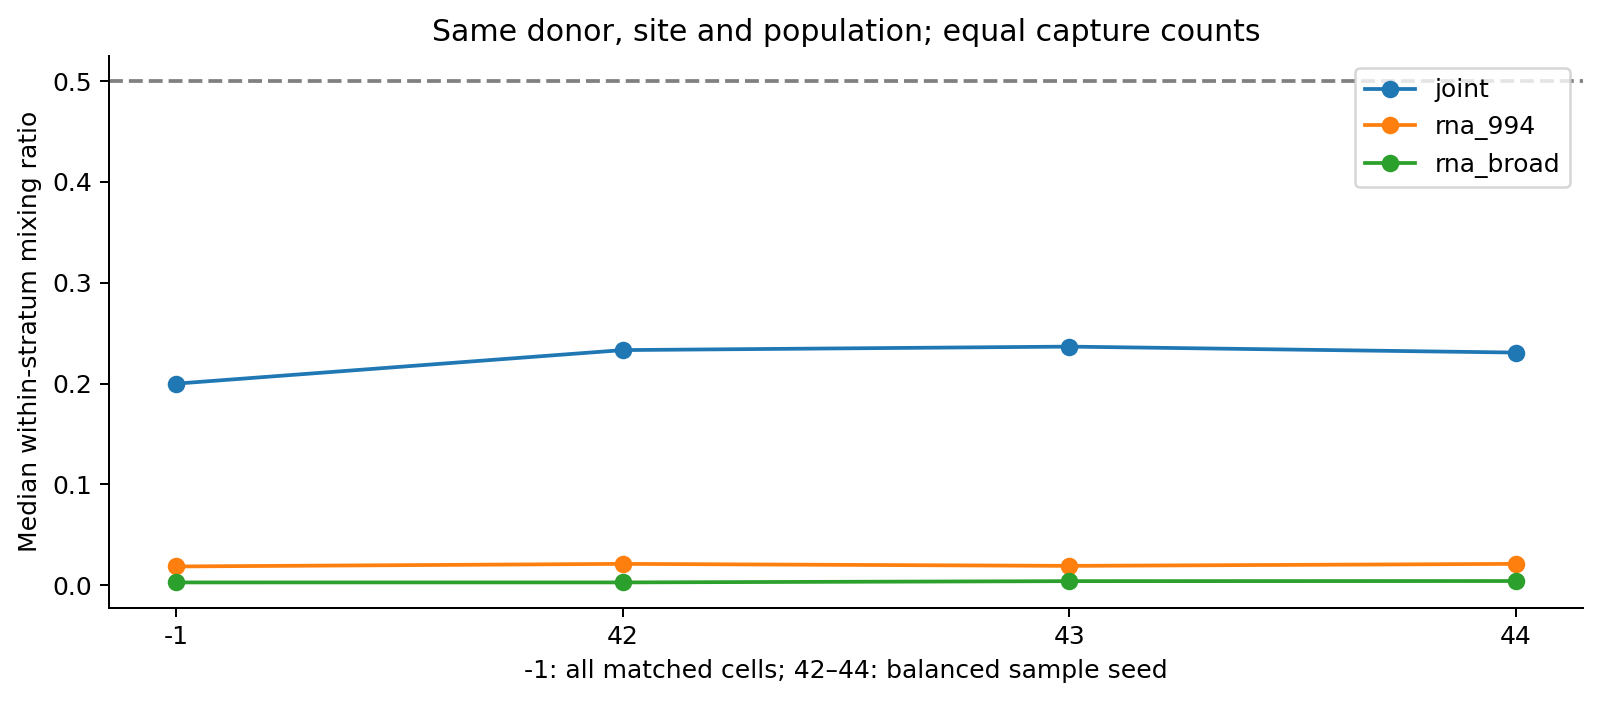

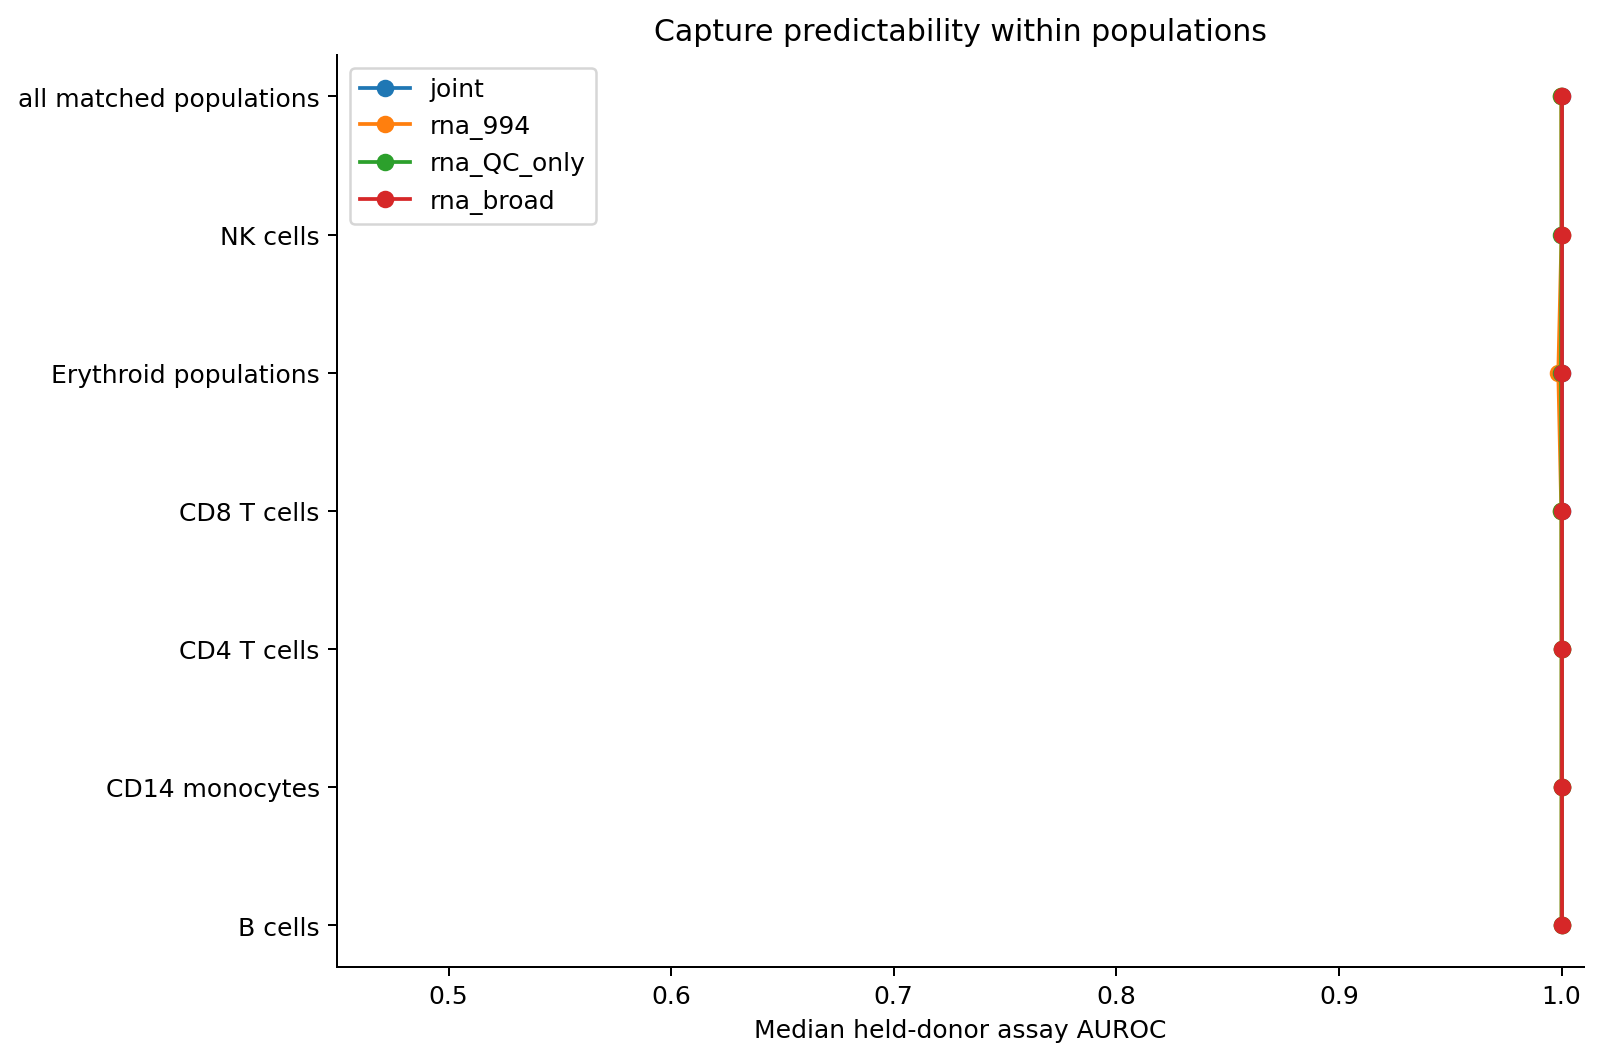

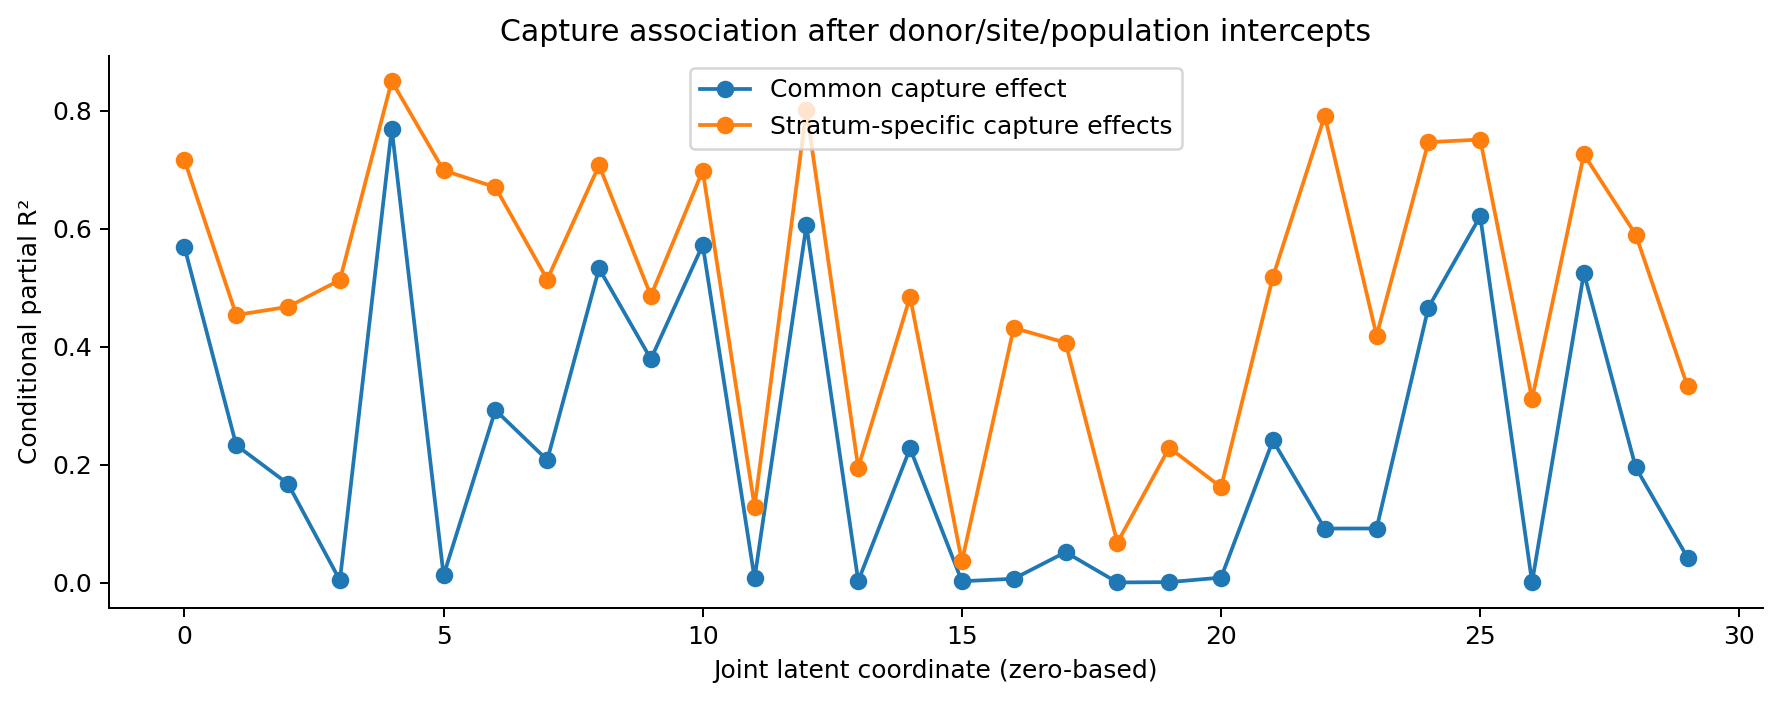

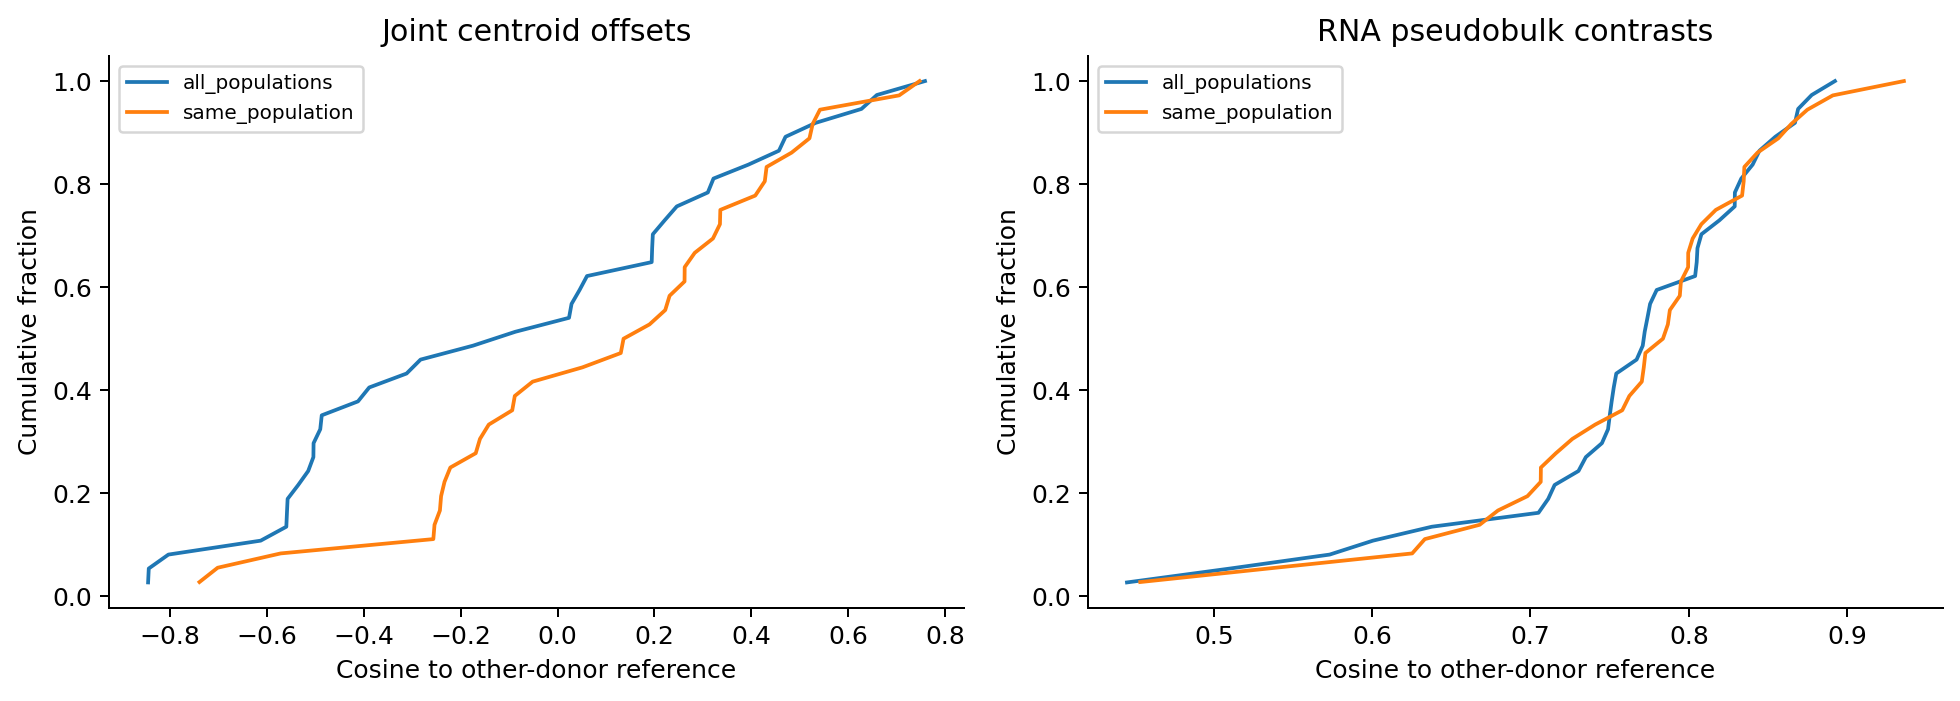

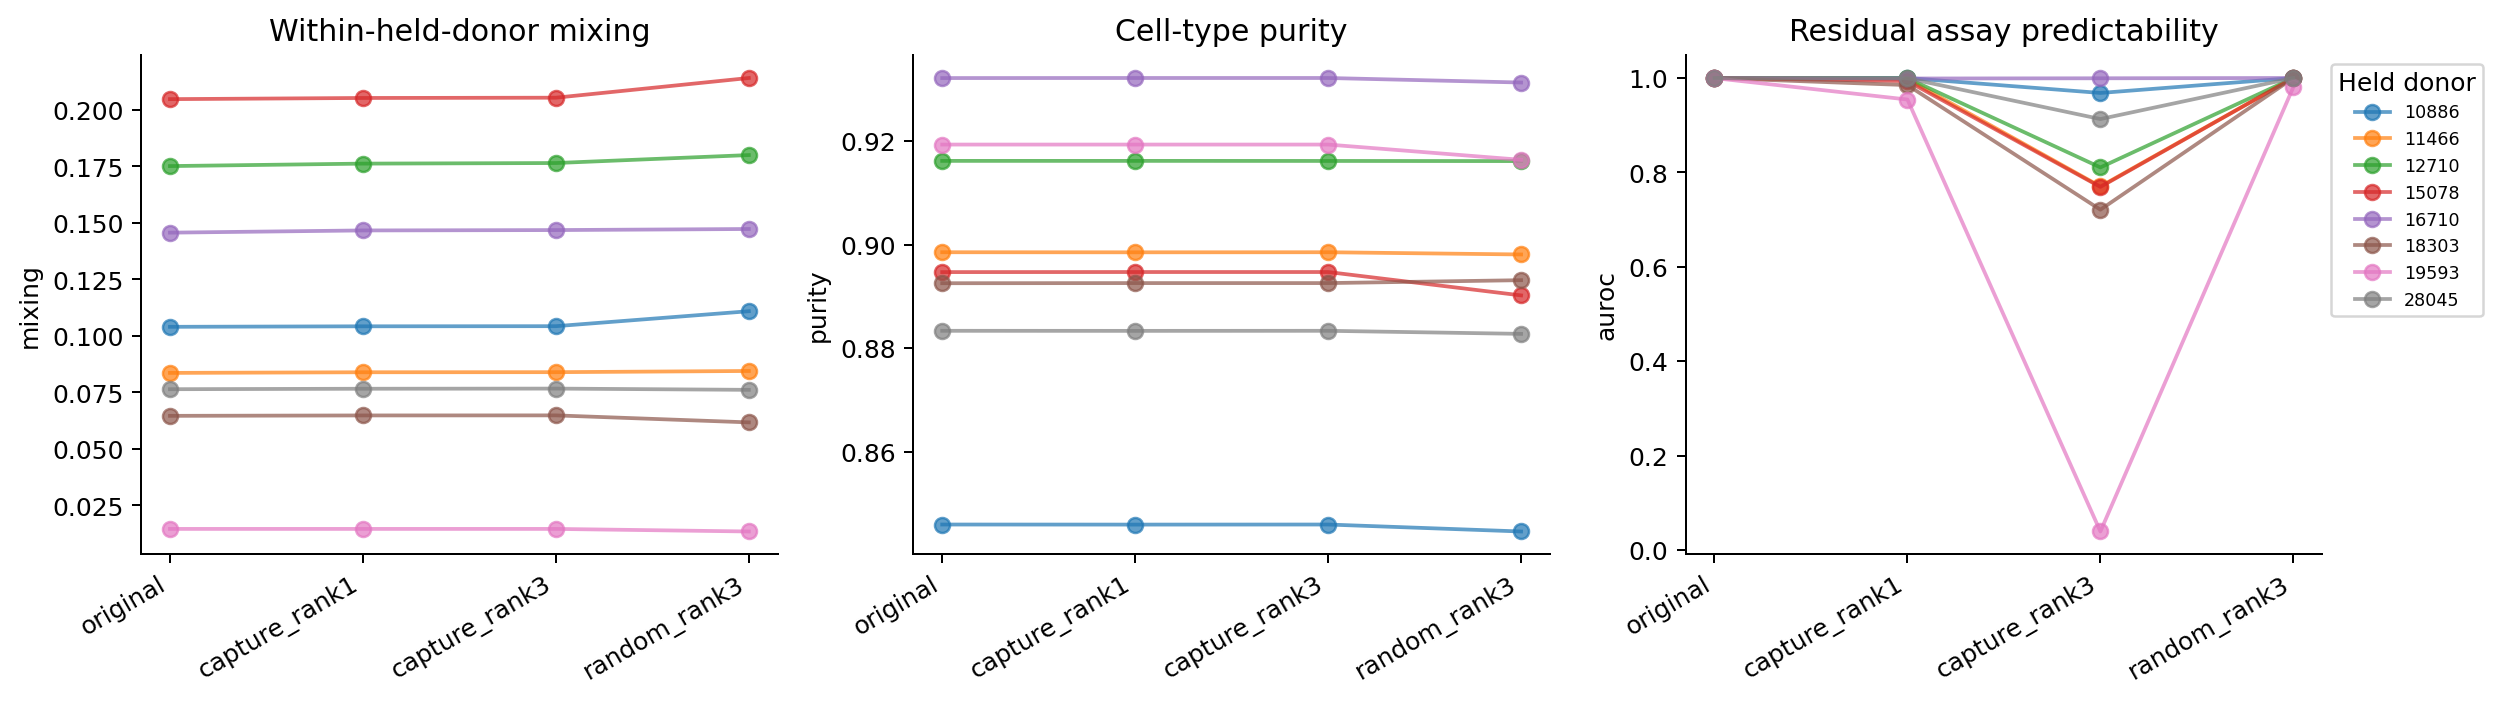

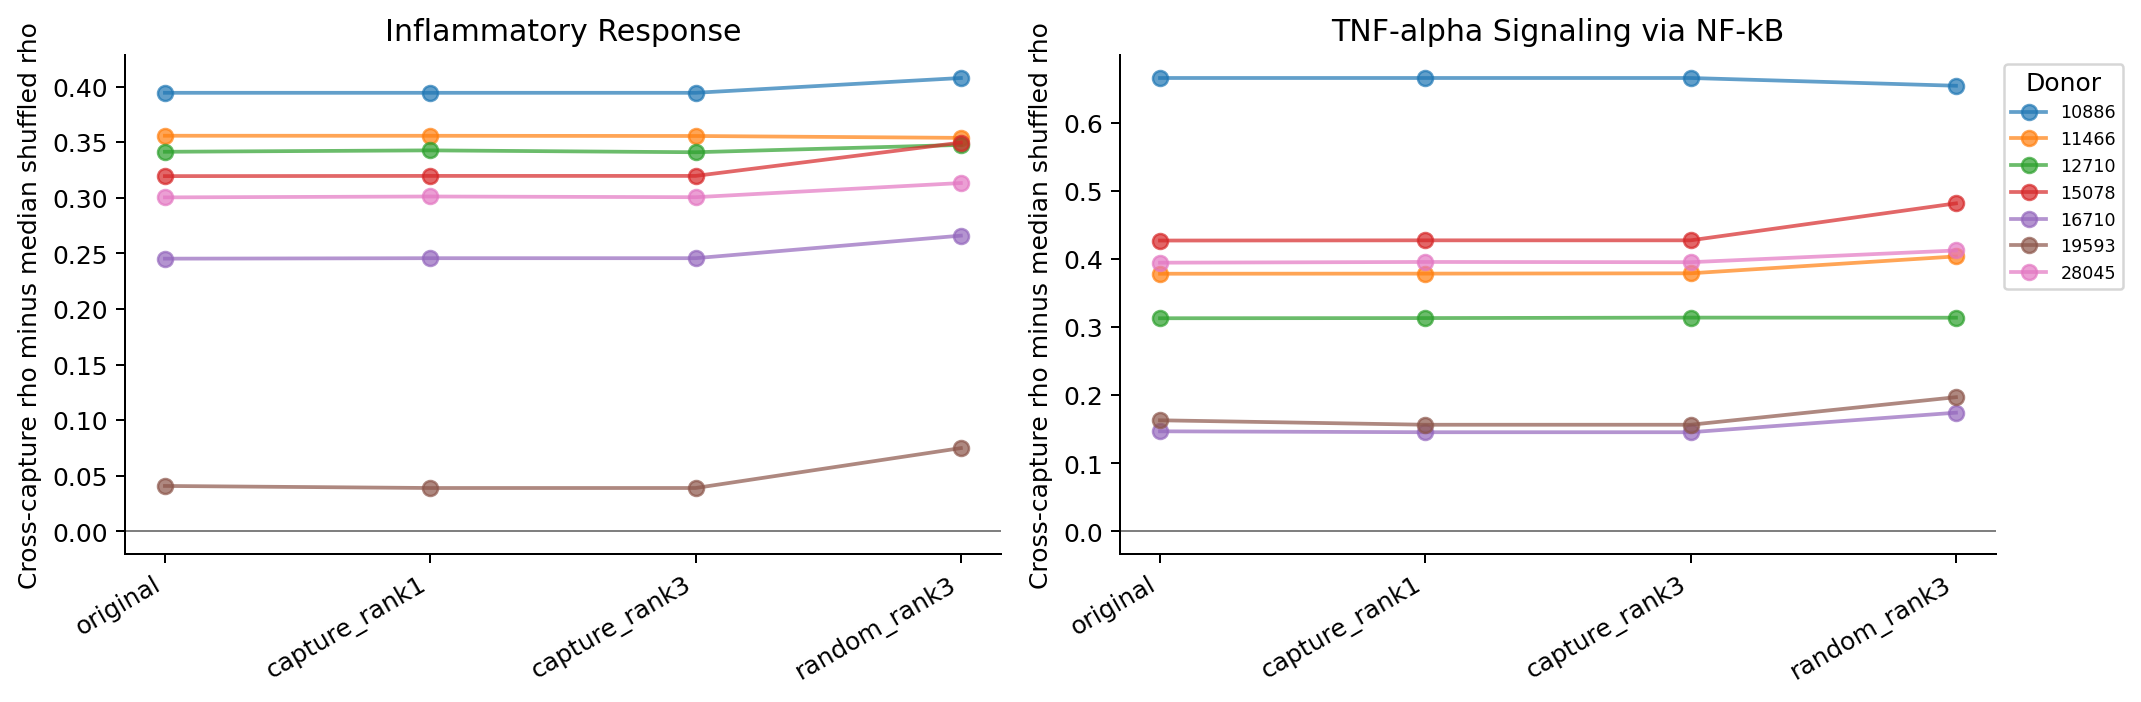

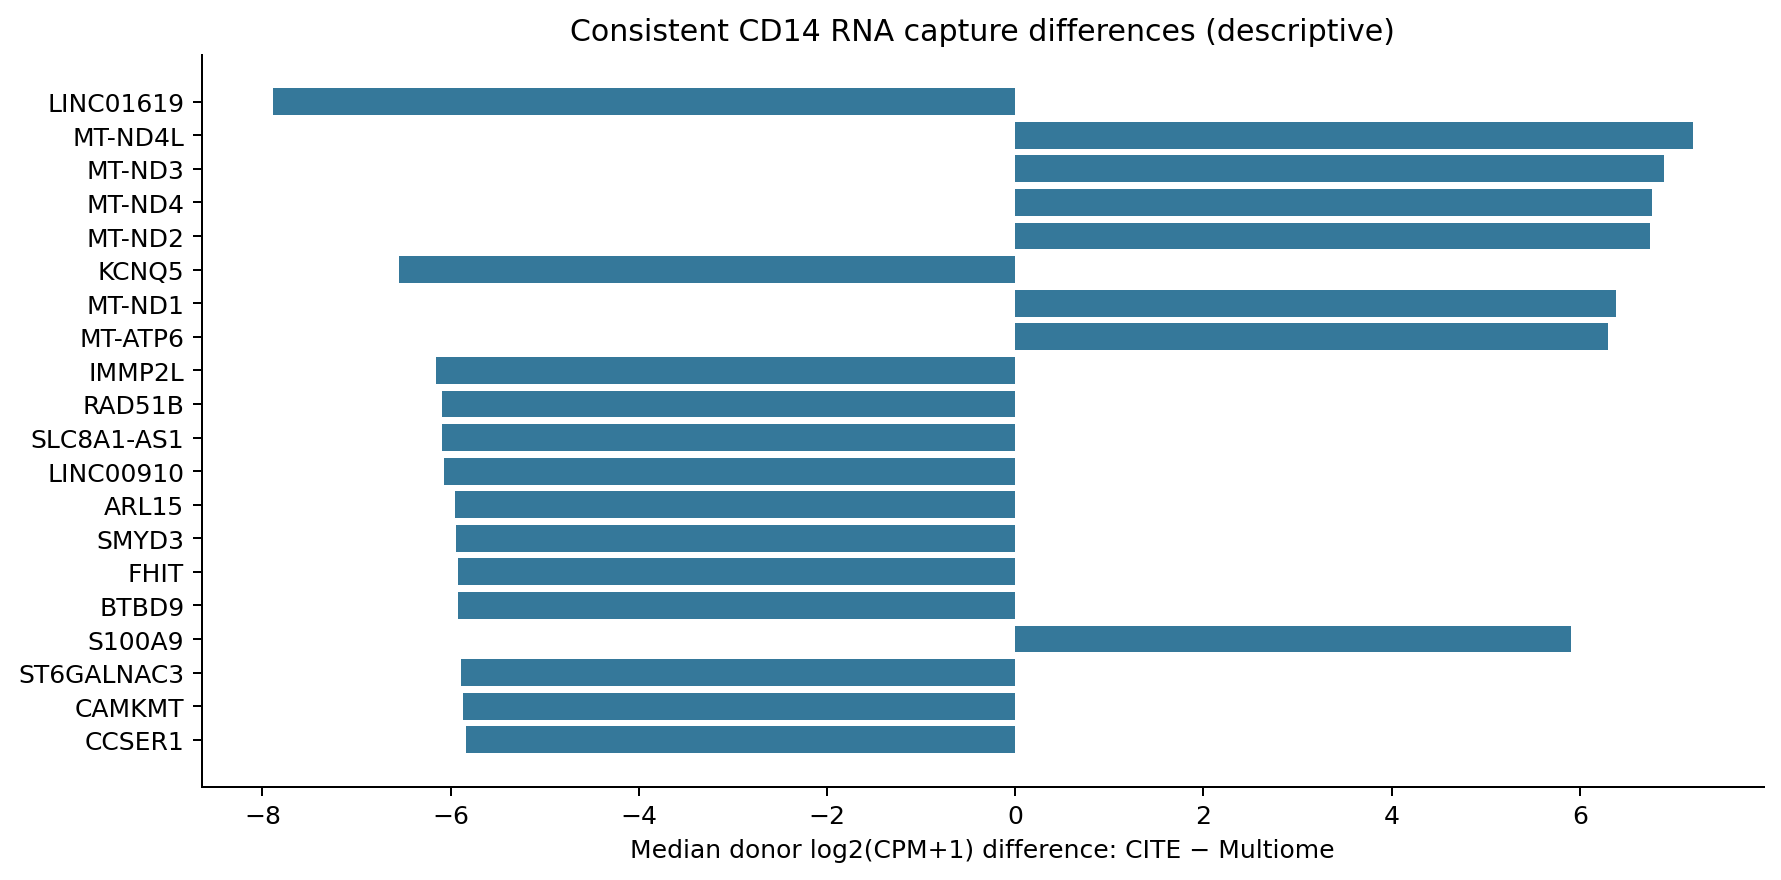

# Main findings

- Exact donor/site/population comparisons: **34/37 concern groups**; composition-adjusted median mixing ratio **0.200**. Equal-count sampling over three seeds yields median **0.233**.
- Within-population held-donor capture prediction: median AUROC **1.0000** across 35 tests.
- Removing three classifier directions learned on other donors changes within-held-donor mixing by **+0.05 percentage points** (descriptive donor-bootstrap 95% interval +0.02 to +0.09); purity changes **+0.00 points**. Random rank-3 removal changes mixing by +0.24 points. Refitted capture classifier median AUROC remains **0.7905**. These directions account for only **0.0331%** of within-stratum latent variance (median held donor).
- RNA depth/detection/mitochondrial/ribosomal summaries alone give within-population held-donor median AUROC **1.0000**. These quantities can reflect both measurement and biology; they are not automatically safe regression targets.

# Diagnosis

Capture separation persists inside the same donor, site and population, so donor/site composition alone is not the explanation. RNA differences between captures also recur across donors. Broad identities can remain distinct while each population retains capture-associated structure. The observations do not distinguish technical assay effects from unmeasured state/subtype selection; capture is not randomized. Strong classifier signals can occupy very low-variance directions and therefore contribute little to Euclidean neighborhood distances. After projection, some held-donor classifier relations reverse: median orientation-free separability is 0.8618; this post-hoc statistic is descriptive, not predictive accuracy. Low or below-chance AUROC alone does not prove successful alignment. Directional heterogeneity and full-module checks must guide any proposed integration.

# Recommended next step

Before nb15, prioritize a controlled comparison of population-conditioned RNA-bridge alignment against the existing joint model, with donor-held-out evaluation and exact site/population overlap. Do not use global coordinate removal or simply increase training duration. Audit recurring RNA capture differences and within-population subtype composition before deciding which assay-associated signals may safely be removed.

Accept a future model only if same-site donor/type mixing improves, cell-type purity loses no more than 0.02, and full inflammatory/TNF gradients show no more than 0.05 loss relative to the matched baseline. These are exploratory prespecified screens, not proof of equivalence. No generative model was trained, cells were not paired, and no missing-modality prediction or molecular causality was validated.


In [8]:
deltas,decisions,report=run.finish()
display(deltas)
display(decisions)
for path in sorted((run.output/'figures').glob('*.png')):
    display(Image(filename=str(path)))
display(Markdown(report))